🧠 CENÁRIO 1 — VENDAS (básico)
* Qual produto vende mais?
* Qual produto vende menos?
* Qual produto gera mais faturamento?
* Em quais meses vendemos mais?
* Qual cidade compra mais?

In [ ]:
import pandas as pd

vendas = pd.read_csv('vendas.csv')
display(vendas)

In [ ]:
# Qual produto vende mais?

vende_mais = vendas.groupby('produto')['quantidade'].sum().idxmax()
display(vende_mais)

In [ ]:
# Qual produto vende menos?

vende_menos = vendas.groupby('produto')['quantidade'].sum().idxmin()
display(vende_menos)

In [ ]:
# Qual produto gera mais faturamento?

vendas['faturamento'] = vendas['preco'] * vendas['quantidade']

mais_faturado = vendas.groupby('produto')['faturamento'].sum().idxmax()
display(mais_faturado)

In [ ]:
# Em quais meses vendemos mais?

vendas['data'] = pd.to_datetime(vendas['data'])
vendas['mes'] = vendas['data'].dt.strftime('%B')

meses_mais_vendidos = vendas.groupby('mes')['faturamento'].sum().idxmax()
display(meses_mais_vendidos)

In [ ]:
# Qual cidade compra mais?

cidade_mais_compra = vendas.groupby('cidade')['quantidade'].sum().idxmax()
display(cidade_mais_compra)

In [ ]:
import matplotlib.pyplot as plt

vendas.groupby('produto')['preco'].sum().sort_values().plot(kind='barh')
plt.title('Total de preços dos produtos')
plt.show()

💰 CENÁRIO 2 — FINANCEIRO
* Qual mês teve maior faturamento?
* Qual categoria gera mais dinheiro?
* Existe produto que vende bem mas fatura pouco?
* Qual canal gera mais receita?

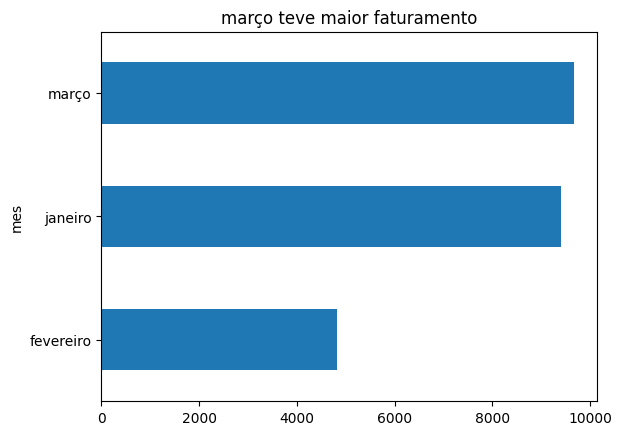

In [67]:
# Qual mês teve maior faturamento?

vendas.groupby('mes')['faturamento'].sum().plot(kind='barh')
maior_faturamento_mes = vendas.groupby('mes')['faturamento'].sum().idxmax()
plt.title(f'{maior_faturamento_mes} teve maior faturamento')
plt.show()

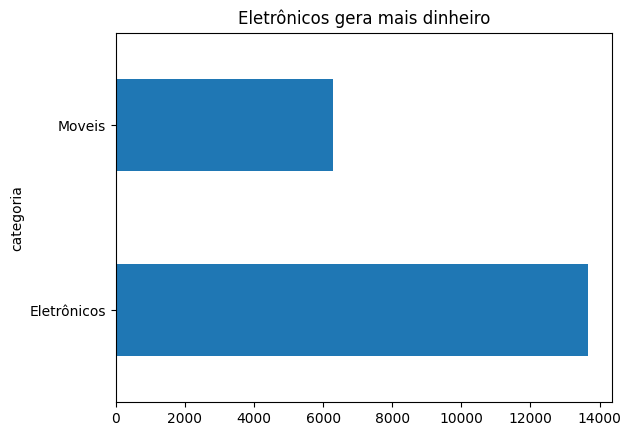

In [ ]:
# Qual categoria gera mais dinheiro?

vendas.groupby('categoria')['preco'].sum().plot(kind='barh')
catego_mais_dinheiro = vendas.groupby('categoria')['preco'].sum().idxmax()
plt.title(f'{catego_mais_dinheiro} gera mais dinheiro')
plt.show()

In [97]:
# Existe produto que vende bem mas fatura pouco?

import plotly.express as px

fatura_pouco = vendas.groupby('produto').agg(
    quantidade_total=('quantidade', 'sum'),
    faturamento_total=('faturamento', 'sum')
).reset_index()

fig = px.bar(
    fatura_pouco,
    x='produto',
    y=['quantidade_total', 'faturamento_total'],
    barmode='group',
    title='Quantidade x Faturamento por Produto'
)

fig.show()

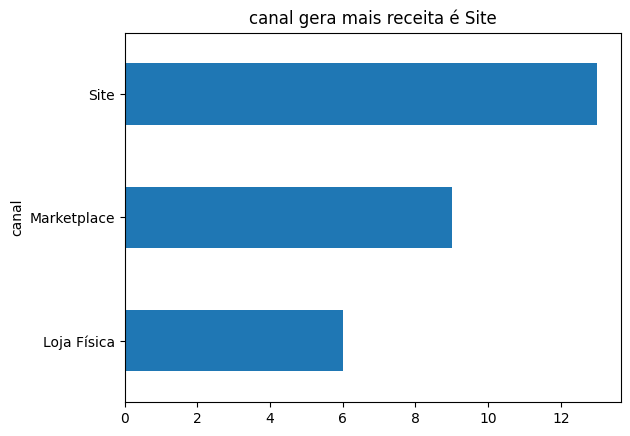

In [99]:
# Qual canal gera mais receita?

vendas.groupby('canal')['quantidade'].sum().plot(kind='barh')
canal_receita = vendas.groupby('canal')['quantidade'].sum().idxmax()
plt.title(f'canal gera mais receita é {canal_receita}')
plt.show()